# Primary Sclerosing Cholangitis — Visium

Concatenate 8 Visium liver sections (CELLxGENE) into a single AnnData:

| Donor | Disease | Sections |
|-------|---------|----------|
| PSC011 | Primary sclerosing cholangitis | A1, B1, C1, D1 |
| C73 | Normal (control) | A1, B1, C1, D1 |

All files share the same gene set (35,477 genes, 4,992 spots each). The `sample_id` is extracted from the dataset title (e.g. `PSC011_A1`).

In [3]:
from __future__ import annotations

import os
import re
from pathlib import Path

os.environ.setdefault("KMP_WARNINGS", "0")

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq

pd.set_option("display.max_columns", 120)

PROJECT_ROOT = Path("/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling")
DATA_DIR = Path("/Volumes/processing/cellxgene/cellxgene_visium/primary-sclerosing-cholangitis")

OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "psc-visium"
OUTPUT_PATH = OUTPUT_DIR / "psc_visium_combined.h5ad"

WRITE_OUTPUT = False

h5ad_files = sorted(p for p in DATA_DIR.glob("*.h5ad") if not p.name.startswith("._"))
print(f"Found {len(h5ad_files)} h5ad files")

Found 8 h5ad files


## Load and tag each section

In [4]:
adatas = {}
for path in h5ad_files:
    a = ad.read_h5ad(path)

    # Extract sample_id from the title (e.g. "...sample PSC011_A1" → "PSC011_A1")
    title = a.uns.get("title", "")
    match = re.search(r"sample\s+(\S+)$", title)
    sample_id = match.group(1) if match else path.stem[:8]

    a.obs["sample_id"] = pd.Categorical([sample_id] * a.n_obs)
    a.obs["dataset_file"] = path.stem
    a.var_names_make_unique()
    a.obs_names_make_unique()

    adatas[sample_id] = a
    print(f"  {sample_id:12s}  {a.n_obs:>5,} spots  donor={a.obs['donor_id'].iloc[0]}  disease={a.obs['disease'].iloc[0]}")

print(f"\nTotal: {sum(a.n_obs for a in adatas.values()):,} spots across {len(adatas)} sections")

  PSC011_A1     4,992 spots  donor=PSC011  disease=primary sclerosing cholangitis
  C73_C1        4,992 spots  donor=C73  disease=normal
  PSC011_B1     4,992 spots  donor=PSC011  disease=primary sclerosing cholangitis
  C73_B1        4,992 spots  donor=C73  disease=normal
  C73_D1        4,992 spots  donor=C73  disease=normal
  C73_A1        4,992 spots  donor=C73  disease=normal
  PSC011_D1     4,992 spots  donor=PSC011  disease=primary sclerosing cholangitis
  PSC011_C1     4,992 spots  donor=PSC011  disease=primary sclerosing cholangitis

Total: 39,936 spots across 8 sections


## Concatenate

In [6]:
adata = ad.concat(
    adatas,
    label="sample_id",
    merge="same",
    join="inner",
    index_unique="-",
)

adata.obs_names_make_unique()
adata.var_names_make_unique()

print(adata)
print(f"\nobsm keys: {list(adata.obsm.keys())}")
adata.obs["sample_id"].value_counts()

AnnData object with n_obs × n_vars = 39936 × 35477
    obs: 'in_tissue', 'array_row', 'array_col', 'mapped_reference_annotation', 'donor_id', 'self_reported_ethnicity_ontology_term_id', 'donor_living_at_sample_collection', 'sample_uuid', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_derivation_process', 'tissue_type', 'tissue_section_uuid', 'tissue_section_thickness', 'library_uuid', 'assay_ontology_term_id', 'sequencing_platform', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'disease_ontology_term_id', 'sex_ontology_term_id', 'percent.mt', 'nCount_Spatial', 'nFeature_Spatial', 'nCount_SCT', 'nFeature_SCT', 'suspension_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'sample_id', 'dataset_file'
    var: 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    obsm: 'X_pca', 'X_umap', 'spatial'


sample_id
PSC011_A1    4992
C73_C1       4992
PSC011_B1    4992
C73_B1       4992
C73_D1       4992
C73_A1       4992
PSC011_D1    4992
PSC011_C1    4992
Name: count, dtype: int64

In [7]:
# Overview of the combined metadata
adata.obs.groupby(["donor_id", "disease", "sample_id"], observed=True).size().reset_index(name="n_spots")

,donor_id,disease,sample_id,n_spots
0,C73,normal,C73_C1,4992
1,C73,normal,C73_B1,4992
2,C73,normal,C73_D1,4992
3,C73,normal,C73_A1,4992
4,PSC011,primary sclerosing cholangitis,PSC011_A1,4992
5,PSC011,primary sclerosing cholangitis,PSC011_B1,4992
6,PSC011,primary sclerosing cholangitis,PSC011_D1,4992
7,PSC011,primary sclerosing cholangitis,PSC011_C1,4992


## QC

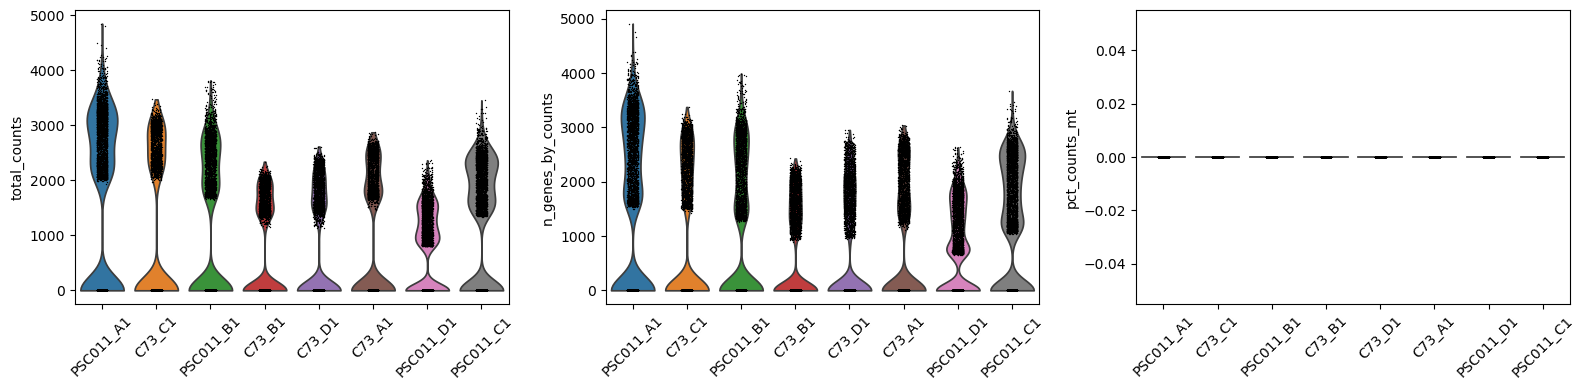

,total_counts,n_genes_by_counts,pct_counts_mt
sample_id,,,
PSC011_A1,2261.811523,1837.0,0.0
C73_C1,0.000000,0.0,0.0
PSC011_B1,1737.621094,1359.5,0.0
C73_B1,0.000000,0.0,0.0
C73_D1,0.000000,0.0,0.0
C73_A1,0.000000,0.0,0.0
PSC011_D1,957.812134,761.0,0.0
PSC011_C1,1642.025513,1395.5,0.0


In [8]:
adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["total_counts", "n_genes_by_counts", "pct_counts_mt"]):
    sc.pl.violin(adata, col, groupby="sample_id", ax=ax, show=False, rotation=45)
plt.tight_layout()
plt.show()

adata.obs.groupby("sample_id", observed=True)[["total_counts", "n_genes_by_counts", "pct_counts_mt"]].median()

## Spatial overview

In [ ]:
adata[adata.obs.in_tissue == 1]

,in_tissue,array_row,array_col,mapped_reference_annotation,donor_id,self_reported_ethnicity_ontology_term_id,donor_living_at_sample_collection,sample_uuid,sample_preservation_method,tissue_ontology_term_id,development_stage_ontology_term_id,sample_derivation_process,tissue_type,tissue_section_uuid,tissue_section_thickness,library_uuid,assay_ontology_term_id,sequencing_platform,is_primary_data,cell_type_ontology_term_id,author_cell_type,disease_ontology_term_id,sex_ontology_term_id,percent.mt,nCount_Spatial,nFeature_Spatial,nCount_SCT,nFeature_SCT,suspension_type,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid,sample_id,dataset_file,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt
AAACAAGTATCTCCCA-1-PSC011_A1,1,50,102,GENCODE 32,PSC011,unknown,True,ce83db34-64ae-4600-9637-630e3b0cb0e7,OCT embedding,UBERON:0001117,HsapDv:0000226,resection,tissue,d2292fee-98c4-4028-812d-fdfea5b21076,16 μm,755360e9-1a2c-44e3-97ea-7430fee8812d,EFO:0022857,Illumina NovaSeq 6000,True,CL:0019029,C-Hepato2,MONDO:0013433,PATO:0000383,5.385284,7531.0,1998.0,10313.0,2012.0,na,centrilobular region hepatocyte,Visium Spatial Gene Expression V1,primary sclerosing cholangitis,female,caudate lobe of liver,unknown,prime adult stage,gFD!+Zqd(i,PSC011_A1,43cd0dbc-4e6c-433f-b143-8e6367e17fed,2011,2236.672119,0.0,0.0
AAACAATCTACTAGCA-1-PSC011_A1,1,3,43,GENCODE 32,PSC011,unknown,True,ce83db34-64ae-4600-9637-630e3b0cb0e7,OCT embedding,UBERON:0001117,HsapDv:0000226,resection,tissue,d2292fee-98c4-4028-812d-fdfea5b21076,16 μm,755360e9-1a2c-44e3-97ea-7430fee8812d,EFO:0022857,Illumina NovaSeq 6000,True,CL:0000182,MiscHep,MONDO:0013433,PATO:0000383,4.203024,43913.0,5272.0,10796.0,2956.0,na,hepatocyte,Visium Spatial Gene Expression V1,primary sclerosing cholangitis,female,caudate lobe of liver,unknown,prime adult stage,OsSlEREYZW,PSC011_A1,43cd0dbc-4e6c-433f-b143-8e6367e17fed,2952,3007.414062,0.0,0.0
AAACAGAGCGACTCCT-1-PSC011_A1,1,14,94,GENCODE 32,PSC011,unknown,True,ce83db34-64ae-4600-9637-630e3b0cb0e7,OCT embedding,UBERON:0001117,HsapDv:0000226,resection,tissue,d2292fee-98c4-4028-812d-fdfea5b21076,16 μm,755360e9-1a2c-44e3-97ea-7430fee8812d,EFO:0022857,Illumina NovaSeq 6000,True,CL:0019029,C-Hepato2,MONDO:0013433,PATO:0000383,4.980529,9156.0,2355.0,10374.0,2355.0,na,centrilobular region hepatocyte,Visium Spatial Gene Expression V1,primary sclerosing cholangitis,female,caudate lobe of liver,unknown,prime adult stage,-$<USDZJGm,PSC011_A1,43cd0dbc-4e6c-433f-b143-8e6367e17fed,2353,2507.449707,0.0,0.0
AAACCCGAACGAAATC-1-PSC011_A1,1,45,115,GENCODE 32,PSC011,unknown,True,ce83db34-64ae-4600-9637-630e3b0cb0e7,OCT embedding,UBERON:0001117,HsapDv:0000226,resection,tissue,d2292fee-98c4-4028-812d-fdfea5b21076,16 μm,755360e9-1a2c-44e3-97ea-7430fee8812d,EFO:0022857,Illumina NovaSeq 6000,True,CL:0019029,C-Hepato2,MONDO:0013433,PATO:0000383,6.012658,2935.0,1120.0,10176.0,1608.0,na,centrilobular region hepatocyte,Visium Spatial Gene Expression V1,primary sclerosing cholangitis,female,caudate lobe of liver,unknown,prime adult stage,m|=$6PkM#s,PSC011_A1,43cd0dbc-4e6c-433f-b143-8e6367e17fed,1607,2107.858887,0.0,0.0
AAACCGGAAATGTTAA-1-PSC011_A1,1,54,124,GENCODE 32,PSC011,unknown,True,ce83db34-64ae-4600-9637-630e3b0cb0e7,OCT embedding,UBERON:0001117,HsapDv:0000226,resection,tissue,d2292fee-98c4-4028-812d-fdfea5b21076,16 μm,755360e9-1a2c-44e3-97ea-7430fee8812d,EFO:0022857,Illumina NovaSeq 6000,True,CL:0019029,C-Hepato1,MONDO:0013433,PATO:0000383,5.703971,1275.0,686.0,9278.0,1679.0,na,centrilobular region hepatocyte,Visium Spatial Gene Expression V1,primary sclerosing cholangitis,female,caudate lobe of liver,unknown,prime adult stage,mWV<1+G7(R,PSC011_A1,43cd0dbc-4e6c-433f-b143-8e6367e17fed,1679,2134.776611,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTGTGTGTCAAGA-1-PSC011_C1,1,31,77,GENCODE 32,PSC0

In [13]:
adata = adata[adata.obs.in_tissue == 1]

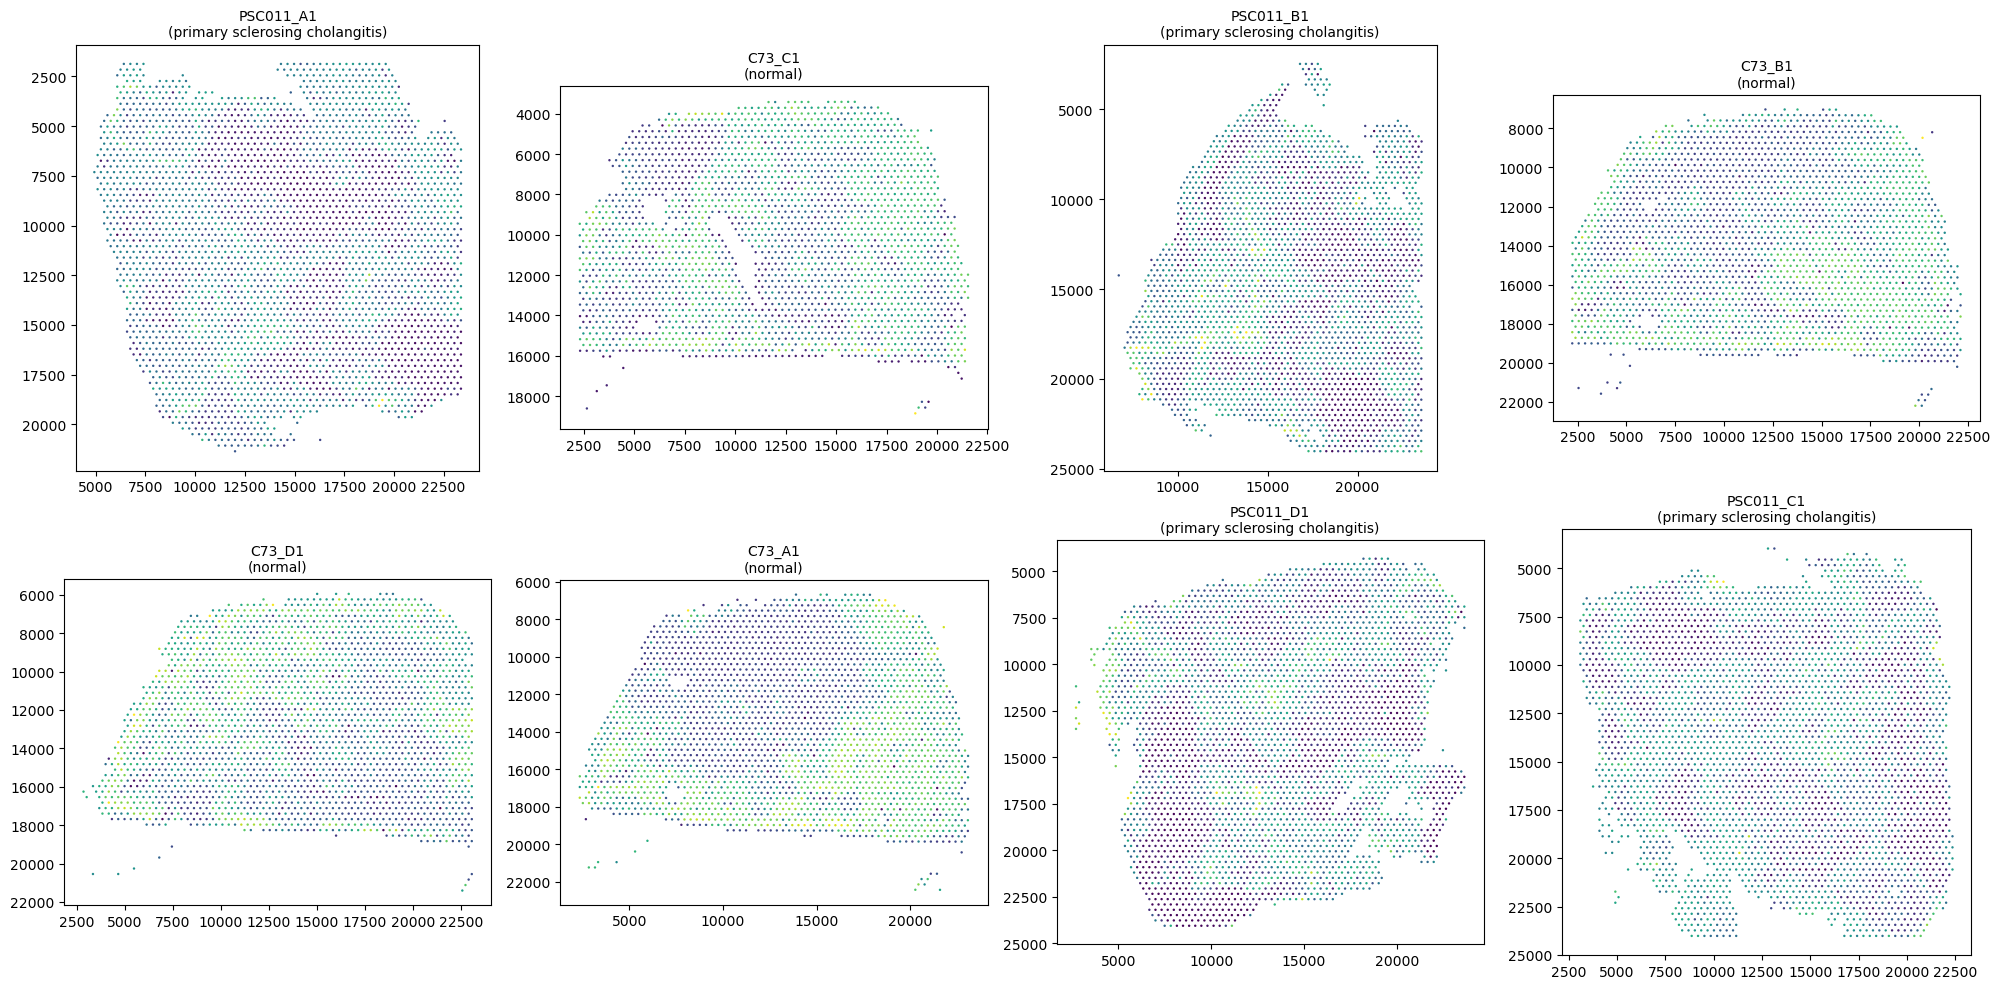

In [15]:
sample_ids = adata.obs["sample_id"].cat.categories
n = len(sample_ids)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, sid in zip(axes.flat, sample_ids):
    sub = adata[adata.obs["sample_id"] == sid]
    coords = sub.obsm["spatial"]
    ax.scatter(coords[:, 0], coords[:, 1], c=sub.obs["total_counts"].values, cmap="viridis", s=3, linewidths=0)
    ax.set_title(f"{sid}\n({sub.obs['disease'].iloc[0]})", fontsize=10)
    ax.set_aspect("equal")
    ax.invert_yaxis()
for ax in axes.flat[n:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [21]:
adata

AnnData object with n_obs × n_vars = 21553 × 35477
    obs: 'in_tissue', 'array_row', 'array_col', 'mapped_reference_annotation', 'donor_id', 'self_reported_ethnicity_ontology_term_id', 'donor_living_at_sample_collection', 'sample_uuid', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_derivation_process', 'tissue_type', 'tissue_section_uuid', 'tissue_section_thickness', 'library_uuid', 'assay_ontology_term_id', 'sequencing_platform', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'disease_ontology_term_id', 'sex_ontology_term_id', 'percent.mt', 'nCount_Spatial', 'nFeature_Spatial', 'nCount_SCT', 'nFeature_SCT', 'suspension_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'sample_id', 'dataset_file', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'feature_name', 'feature_reference', 'feature_biotype',

In [23]:
sq.gr.spatial_neighbors(adata, library_key="sample_id", coord_type="generic", delaunay=True)

In [37]:
adata = sc.read_h5ad('/Volumes/processing/cellxgene/cellxgene_visium_merged/hindlimb_10.1038_s41586-023-06806-x.h5ad')

/Users/chrislangseth/miniforge3/envs/cellcharter/lib/python3.11/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [43]:
adata.obs.source_file.unique()

array(['254ecc3e-57cd-4f1e-8bdf-1b682cc2d309',
       '2c439dce-5aaf-4470-9dae-50ecfbc86e37',
       '54801477-ac3e-47e3-8170-96c5b40d5c10',
       '613e528c-0c6a-4b5d-a269-5bdbafa8794a',
       '69d2ee89-95b1-40af-bfba-5741a1e79c52',
       '70eb992d-8759-44cc-a07b-58d8607aedb4',
       'd06cb48a-3b0b-4218-b876-5abfe5affe0a',
       'e65417a4-e2e0-46ee-b57b-0f76806e1f8e'], dtype=object)

In [36]:
adata.obs.columns

Index(['in_tissue', 'array_row', 'array_col', 'suspension_type',
       'assay_ontology_term_id', 'is_primary_data', 'donor_id',
       'sex_ontology_term_id', 'development_stage_ontology_term_id',
       'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id',
       'tissue_type', 'tissue_ontology_term_id',
       'q05cell_abundance_w_sf_Cardiac_x',
       'q05cell_abundance_w_sf_Endothelial_x',
       'q05cell_abundance_w_sf_Immune_x',
       'q05cell_abundance_w_sf_Mesenchymal_clust12_x',
       'q05cell_abundance_w_sf_Mesenchymal_clust15_x',
       'q05cell_abundance_w_sf_Mesenchymal_clust3_x',
       'q05cell_abundance_w_sf_Mesenchymal_clust6_x',
       'q05cell_abundance_w_sf_Mesenchymal_clust9_x',
       'q05cell_abundance_w_sf_Neural_x', 'annotation',
       'cell_type_ontology_term_id', 'meanscell_abundance_w_sf_Cardiac',
       'meanscell_abundance_w_sf_Endothelial',
       'meanscell_abundance_w_sf_Immune',
       'meanscell_abundance_w_sf_Mesenchymal_clust12

In [26]:
adata.var

,feature_name,feature_reference,feature_biotype,feature_length,feature_type,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts
ENSG00000243485,MIR1302-2HG,NCBITaxon:9606,gene,517,lncRNA,False,0,0.000000,100.000000,0.000000
ENSG00000237613,FAM138A,NCBITaxon:9606,gene,1015,lncRNA,False,0,0.000000,100.000000,0.000000
ENSG00000186092,OR4F5,NCBITaxon:9606,gene,2618,protein_coding,False,0,0.000000,100.000000,0.000000
ENSG00000239945,ENSG00000239945,NCBITaxon:9606,gene,1319,lncRNA,False,0,0.000000,100.000000,0.000000
ENSG00000239906,ENSG00000239906,NCBITaxon:9606,gene,323,lncRNA,False,0,0.000000,100.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
ENSG00000277836,ENSG00000277836,NCBITaxon:9606,gene,288,protein_coding,False,0,0.000000,100.000000,0.000000
ENSG00000278633,ENSG00000278633,NCBITaxon:9606,gene,2404,protein_coding,False,0,0.000000,100.000000,0.000000
ENSG00000276017,ENSG00000276017,NCBITaxon:9606,gene,2404,protein_coding,False,0,0.000000,100.000000,0.000000
ENSG00000278817,ENSG00000278817,NCBITaxon:9606,gene,1213,protein_coding,False,706,0.012694,98.232171,506.965759


In [24]:
adata.write('/Volumes/processing/cellxgene/wrangled/psc-visum.h5ad')

## Filter, normalize, and process

In [ ]:
# Filter to in-tissue spots
adata = adata[adata.obs["in_tissue"] == 1].copy()
print(f"In tissue: {adata.n_obs:,} spots")

sc.pp.filter_genes(adata, min_counts=3)
sc.pp.filter_cells(adata, min_counts=3)
print(f"After filtering: {adata.n_obs:,} spots x {adata.n_vars:,} genes")

adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata.copy()

n_top_genes = min(2000, adata.n_vars)
sc.pp.highly_variable_genes(adata, n_top_genes=n_top_genes, flavor="seurat", subset=True)

sc.tl.pca(adata, svd_solver="arpack")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=min(30, adata.obsm["X_pca"].shape[1]))
sc.tl.umap(adata, min_dist=0.3)
sc.tl.leiden(adata, resolution=1.0, key_added="leiden_1.0")

adata

## Visualization

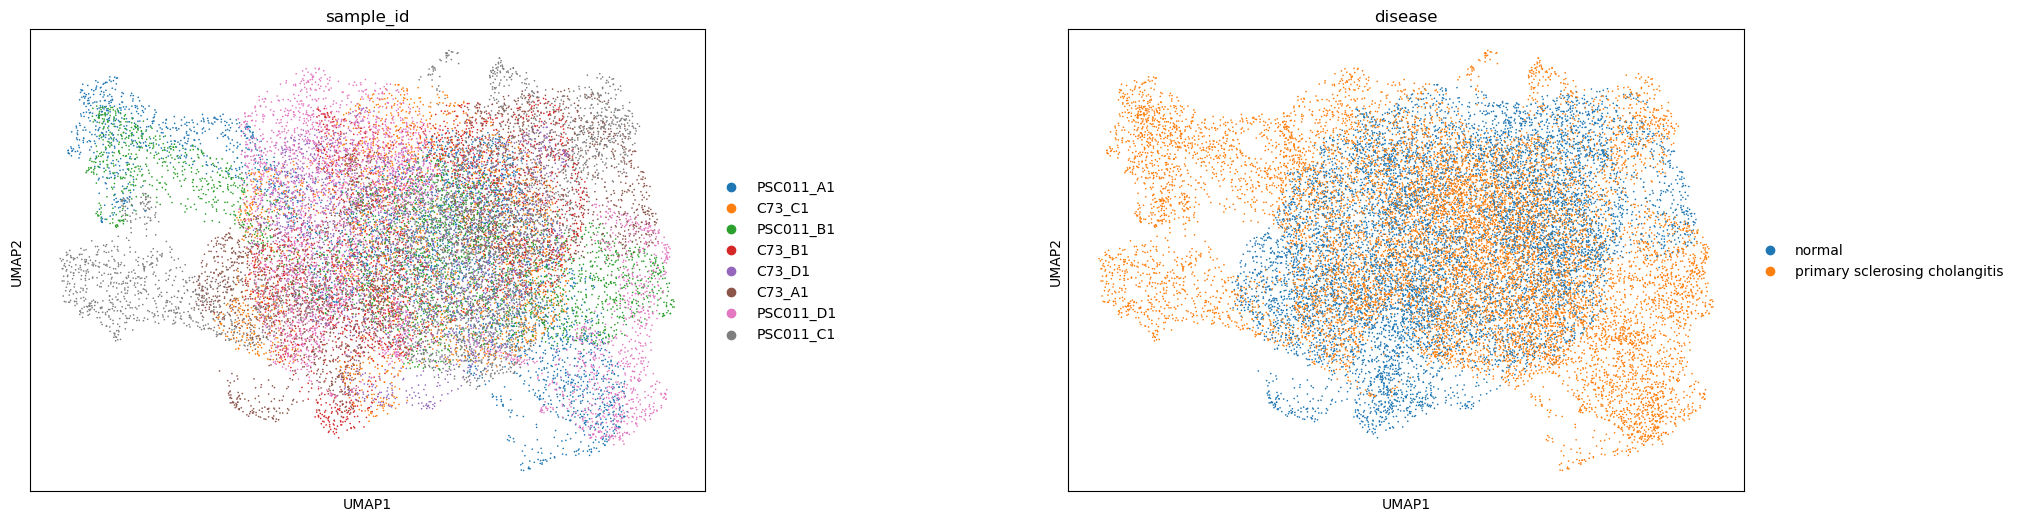

In [19]:
with plt.rc_context({"figure.figsize": (8, 6)}):
    sc.pl.umap(adata, color=["sample_id", "disease"], wspace=0.4, ncols=3)

In [ ]:
# Spatial maps per section colored by Leiden cluster
sample_ids = adata.obs["sample_id"].cat.categories
n = len(sample_ids)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, sid in zip(axes.flat, sample_ids):
    sub = adata[adata.obs["sample_id"] == sid]
    coords = sub.obsm["spatial"]
    codes = sub.obs["leiden_1.0"].astype("category").cat.codes
    ax.scatter(coords[:, 0], coords[:, 1], c=codes, cmap="tab20", s=1.5, linewidths=0)
    ax.set_title(f"{sid}\n({sub.obs['disease'].iloc[0]})", fontsize=10)
    ax.set_aspect("equal")
    ax.invert_yaxis()
for ax in axes.flat[n:]:
    ax.axis("off")
plt.suptitle("Leiden clusters per section", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Spatial neighbors (Squidpy)

## Optional save

In [ ]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if WRITE_OUTPUT:
    adata.write_h5ad(OUTPUT_PATH)
    print(f"Wrote: {OUTPUT_PATH}")
else:
    print(f"WRITE_OUTPUT is False — set to True to save.")
    print(f"Planned output: {OUTPUT_PATH}")

In [ ]:
adata